# 🛠️ Prétraitement — Masked Face Super Resolution

Suite aux conclusions de l'EDA, ce notebook met en place le **pipeline de données minimal** nécessaire pour entraîner les modèles. 

## Pourquoi ce notebook est simple

L'EDA a montré que :
- ✅ Images déjà **128×128 uniforme** → pas de resize physique
- ✅ Mode **RGB uniforme** → pas de conversion
- ✅ Dataset déjà **cropped sur les visages** → pas de détection faciale
- ✅ **97.7%** de paires alignées par filename → pairing direct
- ⚠️ **575 orphelines** dans `part3/train` → à filtrer

→ Le "prétraitement" se réduit à **indexer les paires valides** et **appliquer les transforms à la volée** au moment du chargement. 
**Aucune modification de fichier sur disque.**

## Scope choisi
- **Parts utilisées** : `part1` + `part2` (32 000 images train, 2 000 val, 2 000 test)
- **Part3 exclue** (absence de split `val`, possible drift statistique)
- **Deux tâches en parallèle** pour comparaison :
  - `inpainting` : 128×128 masked → 128×128 unmasked
  - `sr` : 64×64 masked (downscale) → 128×128 unmasked (super-resolution + inpainting)

## Plan
1. Configuration
2. Indexation des paires valides
3. Classe `MaskedFaceDataset`
4. Fabrique de DataLoaders (factory pattern)
5. Sanity check visuel — tâche `inpainting`
6. Sanity check visuel — tâche `sr`
7. Benchmark de chargement
8. Sauvegarde de l'index
9. Synthèse

## 1. Configuration

In [1]:
import os, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

plt.rcParams['figure.dpi'] = 90
pd.set_option('display.max_rows', 40)

print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cpu  |  CUDA: False


In [2]:
# ─── Auto-détection du chemin du dataset ───
# Garde la même logique que l'EDA : cherche d'abord 'dataset' dans cwd et parent
candidates = [
    Path.cwd() / 'dataset',
    Path.cwd().parent / 'dataset',
    Path.cwd() / 'data' / 'raw',
    Path.cwd().parent / 'data' / 'raw',
]
DATA_DIR = next((c for c in candidates if c.is_dir() and (c/'part1').is_dir()), None)
assert DATA_DIR is not None, (
    f"❌ Dataset introuvable. Cherché dans : {[str(c) for c in candidates]}\n"
    f"→ Ajuste DATA_DIR manuellement.")
print(f"✓ DATA_DIR: {DATA_DIR.resolve()}")

# ─── Hyperparamètres du pipeline ───
TRAIN_PARTS = ['part1', 'part2']      # exclut part3
SPLITS = ['train', 'val', 'test']

HR_SIZE   = 128                       # taille native du dataset
LR_SIZE   = 64                        # pour la tâche SR : 2× upscaling
BATCH_SIZE = 32
NUM_WORKERS = 0                       # 0 pour Windows/notebooks, passer à 4 en script

# Où sauvegarder l'index (pour réutilisation sans rescanner)
PROCESSED_DIR = Path.cwd().parent / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
INDEX_CSV = PROCESSED_DIR / 'pairs_index.csv'

print(f"✓ Index sera sauvegardé dans : {INDEX_CSV}")

✓ DATA_DIR: C:\Users\khalid\Desktop\Masked-_Face_Projet\dataset
✓ Index sera sauvegardé dans : c:\Users\khalid\Desktop\Masked-_Face_Projet\data\processed\pairs_index.csv


## 2. Indexation des paires valides

On scanne les dossiers `part{1,2}/{train,val,test}/{masked,unmasked}/` et on ne garde que les filenames présents **des deux côtés**. Le résultat est un DataFrame qui servira de source unique pour les Datasets.

In [3]:
def build_index(data_dir: Path, parts, splits=('train','val','test')) -> pd.DataFrame:
    """Construit l'index des paires valides (filenames communs masked∩unmasked)."""
    rows = []
    for part in parts:
        for split in splits:
            m_dir = data_dir / part / split / 'masked'
            u_dir = data_dir / part / split / 'unmasked'
            if not (m_dir.is_dir() and u_dir.is_dir()):
                continue
            m_files = {p.name: p for p in m_dir.glob('*.png')}
            u_files = {p.name: p for p in u_dir.glob('*.png')}
            common  = sorted(set(m_files) & set(u_files))
            for name in common:
                rows.append({
                    'filename'     : name,
                    'path_masked'  : str(m_files[name]),
                    'path_unmasked': str(u_files[name]),
                    'part'         : part,
                    'split'        : split,
                })
    return pd.DataFrame(rows)

index_df = build_index(DATA_DIR, TRAIN_PARTS, SPLITS)
print(f"✓ Index construit : {len(index_df):,} paires\n")
print("Répartition par (part, split) :")
print(index_df.groupby(['part','split']).size().unstack(fill_value=0))

✓ Index construit : 20,000 paires

Répartition par (part, split) :
split  test  train   val
part                    
part1  1000   8000  1000
part2  1000   8000  1000


In [4]:
# Contrôles de qualité
print("— Head :")
print(index_df.head(3).to_string(index=False))

# Vérif : aucun doublon de filename dans un même split
dup = index_df.groupby(['split','filename']).size()
dup = dup[dup > 1]
print(f"\n— Doublons (filename répété dans un même split) : {len(dup)}")

# Vérif : les fichiers référencés existent bien (échantillon de 100)
sample_check = index_df.sample(min(100, len(index_df)), random_state=SEED)
missing = sum(not (Path(r.path_masked).is_file() and Path(r.path_unmasked).is_file()) 
              for r in sample_check.itertuples())
print(f"— Fichiers manquants sur échantillon de {len(sample_check)} : {missing}")

— Head :
   filename                                                                        path_masked                                                                        path_unmasked  part split
0000002.png c:\Users\khalid\Desktop\Masked-_Face_Projet\dataset\part1\train\masked\0000002.png c:\Users\khalid\Desktop\Masked-_Face_Projet\dataset\part1\train\unmasked\0000002.png part1 train
0000006.png c:\Users\khalid\Desktop\Masked-_Face_Projet\dataset\part1\train\masked\0000006.png c:\Users\khalid\Desktop\Masked-_Face_Projet\dataset\part1\train\unmasked\0000006.png part1 train
0000008.png c:\Users\khalid\Desktop\Masked-_Face_Projet\dataset\part1\train\masked\0000008.png c:\Users\khalid\Desktop\Masked-_Face_Projet\dataset\part1\train\unmasked\0000008.png part1 train

— Doublons (filename répété dans un même split) : 0
— Fichiers manquants sur échantillon de 100 : 0


## 3. Classe `MaskedFaceDataset`

Une classe qui :
- Lit les paires à la volée depuis l'index
- Supporte les **deux tâches** (`inpainting` ou `sr`) via un paramètre
- Applique les transforms **symétriquement** (même flip sur masked et unmasked)
- Normalise en `[-1, 1]` (standard pour architectures générative / tanh output)

> ℹ️ À migrer vers `src/data/masked_face_dataset.py` une fois stable.

In [5]:
class MaskedFaceDataset(Dataset):
    """
    Dataset unifié pour les tâches d'inpainting et super-résolution + inpainting.

    Args:
        df        : DataFrame avec colonnes path_masked, path_unmasked, split, part
        task      : 'inpainting' (input 128×128) ou 'sr' (input downscalé à lr_size)
        lr_size   : taille de l'input pour la tâche SR (défaut 64 → 2× upscaling)
        hr_size   : taille du target et du masked d'origine (défaut 128)
        augment   : flip horizontal aléatoire (réservé au train)
    
    Returns:
        (x, y) : tensors normalisés [-1, 1]
                 inpainting : x=(3,128,128),    y=(3,128,128)
                 sr         : x=(3,lr,lr),      y=(3,128,128)
    """
    MEAN = [0.5, 0.5, 0.5]
    STD  = [0.5, 0.5, 0.5]

    def __init__(self, df, task='inpainting', lr_size=64, hr_size=128, augment=False):
        assert task in ('inpainting', 'sr'), f"task invalide: {task}"
        self.df = df.reset_index(drop=True)
        self.task = task
        self.lr_size = lr_size
        self.hr_size = hr_size
        self.augment = augment
        self._norm = transforms.Normalize(self.MEAN, self.STD)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        m = Image.open(row['path_masked']).convert('RGB')
        u = Image.open(row['path_unmasked']).convert('RGB')

        # Sécurité : forcer HR_SIZE si dimensions inattendues
        if m.size != (self.hr_size, self.hr_size):
            m = m.resize((self.hr_size, self.hr_size), Image.BICUBIC)
        if u.size != (self.hr_size, self.hr_size):
            u = u.resize((self.hr_size, self.hr_size), Image.BICUBIC)

        # Augmentation symétrique (on ne veut PAS flipper masked sans flipper unmasked)
        if self.augment and random.random() < 0.5:
            m = TF.hflip(m); u = TF.hflip(u)

        # Construction de l'input selon la tâche
        if self.task == 'sr':
            m_input = m.resize((self.lr_size, self.lr_size), Image.BICUBIC)
        else:
            m_input = m

        x = self._norm(TF.to_tensor(m_input))
        y = self._norm(TF.to_tensor(u))
        return x, y

    @classmethod
    def denormalize(cls, tensor):
        """Ramène un tenseur de [-1,1] → [0,1] pour visualisation."""
        t = tensor.clone().cpu()
        if t.ndim == 3:
            for c, (m, s) in enumerate(zip(cls.MEAN, cls.STD)):
                t[c] = t[c] * s + m
        elif t.ndim == 4:
            for c, (m, s) in enumerate(zip(cls.MEAN, cls.STD)):
                t[:, c] = t[:, c] * s + m
        return t.clamp(0, 1)

# Test rapide
_ds = MaskedFaceDataset(index_df.head(2), task='inpainting')
_x, _y = _ds[0]
print(f"✓ Test inpainting : x={tuple(_x.shape)} [{_x.min():.2f},{_x.max():.2f}] | y={tuple(_y.shape)} [{_y.min():.2f},{_y.max():.2f}]")
_ds = MaskedFaceDataset(index_df.head(2), task='sr', lr_size=LR_SIZE)
_x, _y = _ds[0]
print(f"✓ Test sr         : x={tuple(_x.shape)} [{_x.min():.2f},{_x.max():.2f}] | y={tuple(_y.shape)} [{_y.min():.2f},{_y.max():.2f}]")

✓ Test inpainting : x=(3, 128, 128) [-0.99,1.00] | y=(3, 128, 128) [-1.00,1.00]
✓ Test sr         : x=(3, 64, 64) [-1.00,1.00] | y=(3, 128, 128) [-1.00,1.00]


## 4. Fabrique de DataLoaders

Une fonction qui retourne `(train_loader, val_loader, test_loader)` pour une tâche donnée.
On la appelle **deux fois** : une pour l'inpainting, une pour la SR.

In [6]:
def build_dataloaders(index_df, task, batch_size=BATCH_SIZE, lr_size=LR_SIZE,
                      num_workers=NUM_WORKERS, augment_train=True):
    """Renvoie un dict {'train': dl, 'val': dl, 'test': dl} pour une tâche."""
    loaders = {}
    for split in ['train', 'val', 'test']:
        split_df = index_df[index_df['split'] == split]
        if len(split_df) == 0:
            continue
        ds = MaskedFaceDataset(split_df,
                               task=task, lr_size=lr_size,
                               augment=(split == 'train' and augment_train))
        dl = DataLoader(ds,
                        batch_size=batch_size,
                        shuffle=(split == 'train'),
                        num_workers=num_workers,
                        pin_memory=torch.cuda.is_available(),
                        drop_last=(split == 'train'))
        loaders[split] = dl
    return loaders

loaders_inpaint = build_dataloaders(index_df, task='inpainting')
loaders_sr      = build_dataloaders(index_df, task='sr', lr_size=LR_SIZE)

print("🎨 INPAINTING (128→128)")
for k, dl in loaders_inpaint.items():
    print(f"   {k:5} : {len(dl.dataset):,} images  →  {len(dl):,} batches de {dl.batch_size}")
print("\n🔬 SUPER-RÉSOLUTION + INPAINTING (64→128)")
for k, dl in loaders_sr.items():
    print(f"   {k:5} : {len(dl.dataset):,} images  →  {len(dl):,} batches de {dl.batch_size}")

🎨 INPAINTING (128→128)
   train : 16,000 images  →  500 batches de 32
   val   : 2,000 images  →  63 batches de 32
   test  : 2,000 images  →  63 batches de 32

🔬 SUPER-RÉSOLUTION + INPAINTING (64→128)
   train : 16,000 images  →  500 batches de 32
   val   : 2,000 images  →  63 batches de 32
   test  : 2,000 images  →  63 batches de 32


## 5. Sanity check — tâche `inpainting`

On tire un batch du train_loader et on affiche les paires **(input masked, target unmasked)**.

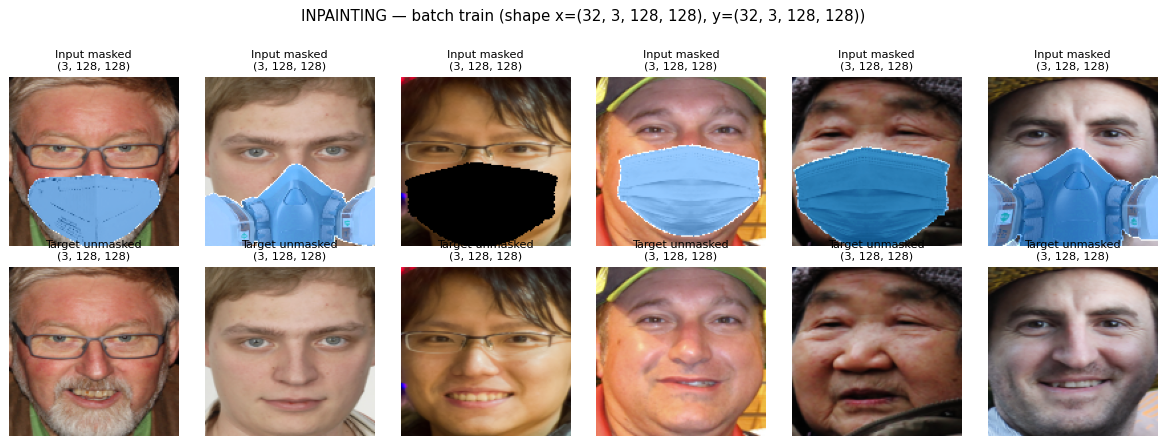

Stats batch : x ∈ [-1.00, 1.00], y ∈ [-1.00, 1.00]


In [7]:
def to_plot(t):
    """Tensor CHW [-1,1] → ndarray HWC [0,1]"""
    return MaskedFaceDataset.denormalize(t).permute(1, 2, 0).numpy()

xb, yb = next(iter(loaders_inpaint['train']))
n = min(6, xb.size(0))

fig, axes = plt.subplots(2, n, figsize=(2.2*n, 4.8))
for i in range(n):
    axes[0, i].imshow(to_plot(xb[i])); axes[0, i].axis('off')
    axes[0, i].set_title(f'Input masked\n{tuple(xb[i].shape)}', fontsize=9)
    axes[1, i].imshow(to_plot(yb[i])); axes[1, i].axis('off')
    axes[1, i].set_title(f'Target unmasked\n{tuple(yb[i].shape)}', fontsize=9)
plt.suptitle(f'INPAINTING — batch train (shape x={tuple(xb.shape)}, y={tuple(yb.shape)})', y=1.02)
plt.tight_layout(); plt.show()

print(f"Stats batch : x ∈ [{xb.min():.2f}, {xb.max():.2f}], y ∈ [{yb.min():.2f}, {yb.max():.2f}]")

## 6. Sanity check — tâche `sr`

Même principe mais l'input est **downscalé à 64×64**. On ajoute une 3ème ligne : l'input bicubic-upscalé à 128 pour visualiser ce que ferait un modèle trivial (baseline de comparaison mentale).

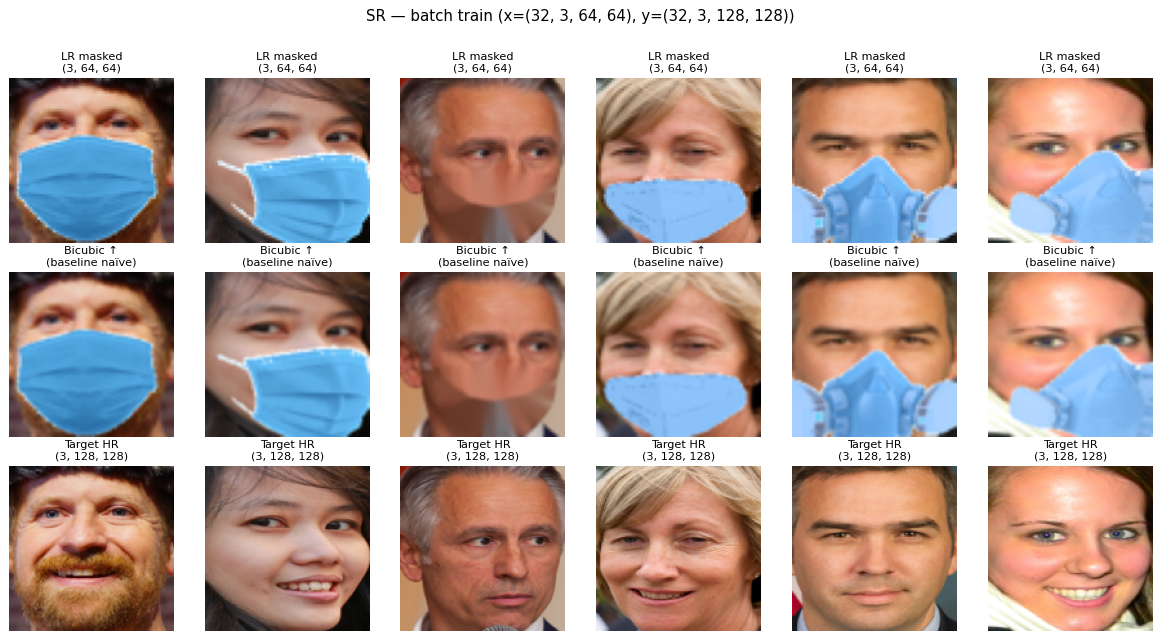

Stats batch : x ∈ [-1.00, 1.00], y ∈ [-1.00, 1.00]


In [8]:
xb, yb = next(iter(loaders_sr['train']))
n = min(6, xb.size(0))

fig, axes = plt.subplots(3, n, figsize=(2.2*n, 7.0))
for i in range(n):
    # Ligne 1 : input LR masked (affiché à sa taille native puis aggrandi pour lisibilité)
    axes[0, i].imshow(to_plot(xb[i])); axes[0, i].axis('off')
    axes[0, i].set_title(f'LR masked\n{tuple(xb[i].shape)}', fontsize=9)

    # Ligne 2 : baseline naïve (bicubic upscale de l'input LR)
    up = TF.resize(xb[i], [HR_SIZE, HR_SIZE], antialias=True)
    axes[1, i].imshow(to_plot(up)); axes[1, i].axis('off')
    axes[1, i].set_title(f'Bicubic ↑\n(baseline naïve)', fontsize=9)

    # Ligne 3 : target HR unmasked
    axes[2, i].imshow(to_plot(yb[i])); axes[2, i].axis('off')
    axes[2, i].set_title(f'Target HR\n{tuple(yb[i].shape)}', fontsize=9)
plt.suptitle(f'SR — batch train (x={tuple(xb.shape)}, y={tuple(yb.shape)})', y=1.01)
plt.tight_layout(); plt.show()

print(f"Stats batch : x ∈ [{xb.min():.2f}, {xb.max():.2f}], y ∈ [{yb.min():.2f}, {yb.max():.2f}]")

## 7. Benchmark de chargement

Vérifier que le pipeline est assez rapide pour ne pas être le goulot d'étranglement pendant l'entraînement. On mesure le temps d'un tour complet du val_loader.

In [9]:
def bench_loader(loader, name):
    n_img = 0
    t0 = time.time()
    for xb, yb in loader:
        n_img += xb.size(0)
    dt = time.time() - t0
    print(f"   {name:20} : {n_img:5,} images en {dt:5.2f}s  →  {n_img/max(dt,1e-6):6.0f} img/s")

print("⏱️  Vitesse de chargement (val_loader, pass complet)")
bench_loader(loaders_inpaint['val'], 'inpainting/val')
bench_loader(loaders_sr['val'],      'sr/val')
print(f"\n(num_workers={NUM_WORKERS} — passer à 4 dans un script Python pour accélérer)")

⏱️  Vitesse de chargement (val_loader, pass complet)
   inpainting/val       : 2,000 images en 14.24s  →     140 img/s
   sr/val               : 2,000 images en 12.39s  →     161 img/s

(num_workers=0 — passer à 4 dans un script Python pour accélérer)


## 8. Sauvegarde de l'index

On sauvegarde l'index sur disque pour que les notebooks suivants (entraînement, évaluation) n'aient pas à rescanner 24 000 fichiers.

In [10]:
index_df.to_csv(INDEX_CSV, index=False)
size_kb = INDEX_CSV.stat().st_size / 1024
print(f"✓ Index sauvegardé : {INDEX_CSV}  ({size_kb:.1f} KB, {len(index_df):,} lignes)")
print(f"\nUtilisation dans un notebook suivant :")
print(f"   index_df = pd.read_csv('{INDEX_CSV.relative_to(Path.cwd().parent) if Path.cwd().parent in INDEX_CSV.parents else INDEX_CSV}')")
print(f"   loaders  = build_dataloaders(index_df, task='inpainting')")

✓ Index sauvegardé : c:\Users\khalid\Desktop\Masked-_Face_Projet\data\processed\pairs_index.csv  (3752.0 KB, 20,000 lignes)

Utilisation dans un notebook suivant :
   index_df = pd.read_csv('data\processed\pairs_index.csv')
   loaders  = build_dataloaders(index_df, task='inpainting')


## 9. Synthèse

In [11]:
n_train = (index_df['split'] == 'train').sum()
n_val   = (index_df['split'] == 'val').sum()
n_test  = (index_df['split'] == 'test').sum()

print("="*65)
print("📋 PIPELINE DE DONNÉES — PRÊT POUR L'ENTRAÎNEMENT")
print("="*65)
print(f"\n▸ DATASET")
print(f"   Scope           : {', '.join(TRAIN_PARTS)}")
print(f"   Train           : {n_train:,} paires")
print(f"   Validation      : {n_val:,} paires")
print(f"   Test            : {n_test:,} paires")

print(f"\n▸ TRANSFORMS")
print(f"   Normalisation   : mean={MaskedFaceDataset.MEAN}, std={MaskedFaceDataset.STD}  →  range [-1, 1]")
print(f"   Augment (train) : RandomHorizontalFlip")

print(f"\n▸ DEUX TÂCHES DISPONIBLES")
print(f"   inpainting  : x=(B,3,128,128)   →  y=(B,3,128,128)")
print(f"   sr          : x=(B,3,{LR_SIZE},{LR_SIZE})     →  y=(B,3,128,128)")

print(f"\n▸ OBJETS EXPORTÉS (utilisables dans le notebook suivant)")
print(f"   index_df, MaskedFaceDataset, build_dataloaders")
print(f"   loaders_inpaint, loaders_sr")

print(f"\n▸ PROCHAINE ÉTAPE")
print(f"   03_baseline_unet.ipynb — U-Net baseline sur les deux tâches")

📋 PIPELINE DE DONNÉES — PRÊT POUR L'ENTRAÎNEMENT

▸ DATASET
   Scope           : part1, part2
   Train           : 16,000 paires
   Validation      : 2,000 paires
   Test            : 2,000 paires

▸ TRANSFORMS
   Normalisation   : mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]  →  range [-1, 1]
   Augment (train) : RandomHorizontalFlip

▸ DEUX TÂCHES DISPONIBLES
   inpainting  : x=(B,3,128,128)   →  y=(B,3,128,128)
   sr          : x=(B,3,64,64)     →  y=(B,3,128,128)

▸ OBJETS EXPORTÉS (utilisables dans le notebook suivant)
   index_df, MaskedFaceDataset, build_dataloaders
   loaders_inpaint, loaders_sr

▸ PROCHAINE ÉTAPE
   03_baseline_unet.ipynb — U-Net baseline sur les deux tâches
